In [119]:
import seaborn as sns
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt

seed = 5
np.random.seed(seed)

result_path = Path("diagrams", "feature_weights_importances")
result_path.mkdir(exist_ok=True)

In [120]:
bias_type = "less_positive_class"
bias_strength = "0.1"
data_set_name = "breast_cancer"

In [121]:
method_name = "fw-mrs-temperature"
data_path = Path("..", "results", "temperature_comparison", data_set_name, bias_type, bias_strength, 
                 method_name, "feature_weights/weights.json")
with open(data_path, 'r') as file:
    all_feature_weights_rf = json.load(file)

data_path = Path("..", "results", "temperature_comparison", data_set_name, bias_type, bias_strength, 
                 method_name, "feature_importances/feature_importances.json")
with open(data_path, 'r') as file:
    all_feature_importances_rf = json.load(file)

In [122]:
iteration = np.random.randint(low=0, high=len(all_feature_weights_rf))
individual_feature_weights_rf = all_feature_weights_rf[iteration]["0.1"]["0.0"]
individual_feature_importances_rf = all_feature_importances_rf[iteration]["0.1"]["0.0"]

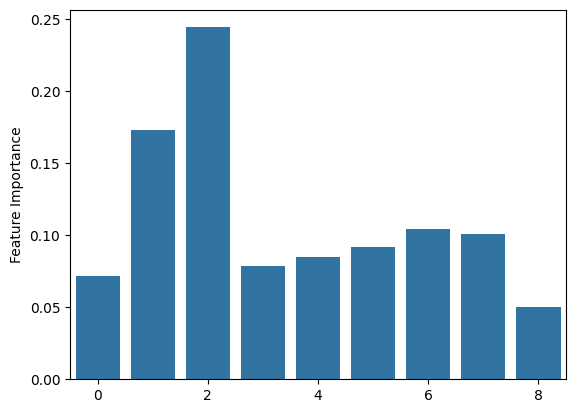

In [123]:
sns.barplot(individual_feature_weights_rf).set(ylabel="Feature Weight")
_ = plt.xticks(list(range(0, len(individual_feature_weights_rf), 2)))
plt.savefig(result_path / "individual_feature_weights_rf.pdf")
plt.clf()

sns.barplot(individual_feature_importances_rf).set(ylabel="Feature Importance")
_ = plt.xticks(list(range(0, len(individual_feature_importances_rf), 2)))
plt.savefig(result_path / "individual_feature_importances_rf.pdf")

In [124]:
method_name = "fw-mrs-temperature-svm"
data_path = Path("..", "results", "temperature_comparison", data_set_name, bias_type, bias_strength, 
                 method_name, "feature_weights", "weights.json")
with open(data_path, 'r') as file:
    all_feature_weights = json.load(file)

data_path = Path("..", "results", "temperature_comparison", data_set_name, bias_type, bias_strength,
                  method_name, "feature_importances", "feature_importances.json")
with open(data_path, 'r') as file:
    all_feature_importances = json.load(file)

individual_feature_weights = all_feature_weights[iteration]["0.1"]["10.0"]
individual_feature_importances = all_feature_importances[iteration]["0.1"]["10.0"]

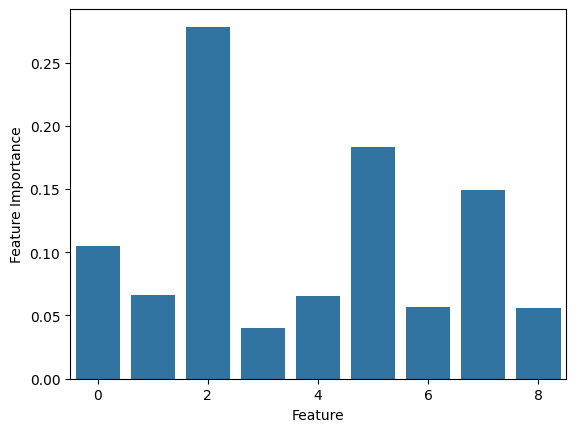

In [125]:
sns.barplot(individual_feature_weights).set(ylabel="Feature Weight", xlabel="Feature")
_ = plt.xticks(list(range(0, len(individual_feature_weights), 2)))
plt.savefig(result_path / "individual_feature_weights_svm.pdf")
plt.clf()

sns.barplot(individual_feature_importances).set(ylabel="Feature Importance", xlabel="Feature")
_ = plt.xticks(list(range(0, len(individual_feature_weights), 2)))
plt.savefig(result_path / "individual_feature_importances_svm.pdf")